<a href="https://colab.research.google.com/github/stephanie465337/Data-Science-Portfolio-C21/blob/main/Projects/Project-4/Spotify_Pass_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project 4: Spotify Music Popularity Prediction


##Problem Definition


This project is a **supervised regression** problem focused on predicting the popularity of a new song using features available prior to its release. We will employ tree-based regression models, such as **Decision Tree Regression**, **Random Forest**, and **XGBoost**, to make these predictions. Regularization techniques will be used to reduce overfitting and assist with feature selection. Model performance will be evaluated using *cross-validated* **Root Mean Squared Error** (*RMSE*), with the aim of minimizing prediction error and understanding which features contribute most to a song’s success.

##Data Collection

In [1]:
import numpy             as np
import pandas            as pd
import matplotlib.pyplot as plt
import seaborn           as sns
import xgboost           as xgb
import pickle
import graphviz

from sklearn.model_selection import train_test_split
from sklearn                 import datasets
from sklearn.metrics         import mean_squared_error
from sklearn.tree            import DecisionTreeRegressor
from sklearn.ensemble        import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from IPython.display         import display
from sklearn                 import tree

In [2]:
url = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv'
url

'https://ddc-datascience.s3.amazonaws.com/Projects/Project.4-Spotify/Data/Spotify.csv'

In [3]:
#Look at the headers
!curl -s -I {url}

HTTP/1.1 200 OK
x-amz-id-2: JyY+jgm99lc3uHTQIpIE5e1PPWGB0CBPD6x+3rkk+KGNI6fNgZITX5p9d5ePpWOzJ9OL6xj/srItTYVZqRn8n6ixFtOpcfLq
x-amz-request-id: 5F0NNYGEB2H7ENXX
Date: Tue, 14 Jul 2026 04:13:11 GMT
Last-Modified: Wed, 04 Oct 2023 17:23:56 GMT
ETag: "65b9875b11e0d7ea03ee2af024f45e99"
x-amz-server-side-encryption: AES256
Accept-Ranges: bytes
Content-Type: text/csv
Content-Length: 738124
Server: AmazonS3



In [4]:
#Download the file
!curl -s -O {url}

In [5]:
#Verify
!ls -la

total 740
drwxr-xr-x 1 root root   4096 Jul 14 04:13 .
drwxr-xr-x 1 root root   4096 Jul 14 04:10 ..
drwxr-xr-x 4 root root   4096 Jun  4 13:32 .config
drwxr-xr-x 1 root root   4096 Jun  4 13:32 sample_data
-rw-r--r-- 1 root root 738124 Jul 14 04:13 Spotify.csv


In [6]:
#Look at the field names
!head -1 Spotify.csv | tr , '\n' | cat -n

     1	Index
     2	Highest Charting Position
     3	Number of Times Charted
     4	Week of Highest Charting
     5	Song Name
     6	Streams
     7	Artist
     8	Artist Followers
     9	Song ID
    10	Genre
    11	Release Date
    12	Weeks Charted
    13	Popularity
    14	Danceability
    15	Energy
    16	Loudness
    17	Speechiness
    18	Acousticness
    19	Liveness
    20	Tempo
    21	Duration (ms)
    22	Valence
    23	Chord


In [7]:
df = pd.read_csv(url)
df

,Index,Highest Charting Position,Number of Times Charted,Week of Highest Charting,Song Name,Streams,Artist,Artist Followers,Song ID,Genre,...,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
0,1,1,8,2021-07-23--2021-07-30,Beggin',"48,633,449",Måneskin,3377762,3Wrjm47oTz2sjIgck11l5e,"['indie rock italiano', 'italian pop']",...,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B
1,2,2,3,2021-07-23--2021-07-30,STAY (with Justin Bieber),"47,248,719",The Kid LAROI,2230022,5HCyWlXZPP0y6Gqq8TgA20,['australian hip hop'],...,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db
2,3,1,11,2021-06-25--2021-07-02,good 4 u,"40,162,559",Olivia Rodrigo,6266514,4ZtFanR9U6ndgddUvNcjcG,['pop'],...,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688,A
3,4,3,5,2021-07-02--2021-07-09,Bad Habits,"37,799,456",Ed Sheeran,83293380,6PQ88X9TkUIAUIZJHW2upE,"['pop', 'uk pop']",...,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591,B
4,5,5,1,2021-07-23--2021-07-30,INDUSTRY BABY (feat. Jack Harlow),"33,948,454",Lil Nas X,5473565,27NovPIUIRrOZoCHxABJwK,"['lgbtq+ hip hop', 'pop rap']",...,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894,D#/Eb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1551,1552,195,1,2019-12-27--2020-01-03,New Rules,"4,630,675",Dua Lipa,27167675,2ekn2ttSfGqwhhate0LSR0,"['dance pop', 'pop', 'uk pop']",...,0.762,0.7,-6.021,0.0694,0.00261,0.153,116.073,209320,0.608,A
1552,1553,196,1,2019-12-27--2020-01-03,Cheirosa - Ao Vivo,"4,623,030",Jorge & Mateus,15019109,2PWjKmjyTZeDpmOUa3a5da,"['sertanejo', 'sertanejo universitario']",...,0.528,0.87,-3.123,0.0851,0.24,0.333,152.37,181930,0.714,B
1553,1554,197,1,2019-12-27--2020-01-03,Havana (feat. Young Thug),"4,620,876",Camila Cabello,22698747,1rfofaqEpACxVEHIZBJe6W,"['dance pop', 'electropop', 'pop', 'post-teen ...",...,0.765,0.523,-4.333,0.03,0.184,0.132,104.988,217307,0.394,D
1554,1555,198,1,2019-12-27--2020-01-03,Surtada - Remix Brega Funk,"4,607,385","Dadá Boladão, Tati Zaqui, OIK",208630,5F8ffc8KWKNawllr5WsW0r,"['brega funk', 'funk carioca']",...,0.832,0.55,-7.026,0.0587,0.249,0.182,154.064,152784,0.881,F


##Data Cleaning

In [8]:
df.shape

(1556, 23)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1556 entries, 0 to 1555
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Index                      1556 non-null   int64 
 1   Highest Charting Position  1556 non-null   int64 
 2   Number of Times Charted    1556 non-null   int64 
 3   Week of Highest Charting   1556 non-null   object
 4   Song Name                  1556 non-null   object
 5   Streams                    1556 non-null   object
 6   Artist                     1556 non-null   object
 7   Artist Followers           1556 non-null   object
 8   Song ID                    1556 non-null   object
 9   Genre                      1556 non-null   object
 10  Release Date               1556 non-null   object
 11  Weeks Charted              1556 non-null   object
 12  Popularity                 1556 non-null   object
 13  Danceability               1556 non-null   object
 14  Energy  

###Target

In [10]:
df['Streams'] = df['Streams'].str.replace(',', '').astype(int)
df['Highest Charting Position'] = 201 - df['Highest Charting Position']
df[['Highest Charting Position', 'Streams']].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Highest Charting Position,1556.0,1.132558e+02,5.814723e+01,1.0,64.00,121.0,164.00,200.0
Streams,1556.0,6.340219e+06,3.369479e+06,4176083.0,4915322.25,5275747.5,6455044.25,48633449.0


In [11]:
target = 'Highest Charting Position'

In [12]:
df[target].isnull().sum()

np.int64(0)

###Unique IDs

In [13]:
identifier_cols = []

for col in df.columns:
    if df[col].nunique() == len(df):
        identifier_cols.append(col)

print(identifier_cols)

['Index', 'Song Name', 'Streams']


In [14]:
df.drop(columns=[
  'Index',
  'Song Name',
  'Song ID',
  'Number of Times Charted',
  'Week of Highest Charting',
  'Streams',
  'Weeks Charted',
  'Popularity'
], inplace=True)
df.head()

,Highest Charting Position,Artist,Artist Followers,Genre,Release Date,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
0,200,Måneskin,3377762,"['indie rock italiano', 'italian pop']",2017-12-08,0.714,0.8,-4.808,0.0504,0.127,0.359,134.002,211560,0.589,B
1,199,The Kid LAROI,2230022,['australian hip hop'],2021-07-09,0.591,0.764,-5.484,0.0483,0.0383,0.103,169.928,141806,0.478,C#/Db
2,200,Olivia Rodrigo,6266514,['pop'],2021-05-21,0.563,0.664,-5.044,0.154,0.335,0.0849,166.928,178147,0.688,A
3,198,Ed Sheeran,83293380,"['pop', 'uk pop']",2021-06-25,0.808,0.897,-3.712,0.0348,0.0469,0.364,126.026,231041,0.591,B
4,196,Lil Nas X,5473565,"['lgbtq+ hip hop', 'pop rap']",2021-07-23,0.736,0.704,-7.409,0.0615,0.0203,0.0501,149.995,212000,0.894,D#/Eb


###Rows

In [15]:
df_blank = df.apply(lambda x: x.astype(str).str.strip().eq('').sum())

df_blank[df_blank > 0]

,0
Artist Followers,11
Genre,11
Release Date,11
Danceability,11
Energy,11
Loudness,11
Speechiness,11
Acousticness,11
Liveness,11
Tempo,11


In [16]:
blank_rows = df[df.apply(lambda x: x.astype(str).str.strip().eq('').any(), axis=1)]

blank_rows

,Highest Charting Position,Artist,Artist Followers,Genre,Release Date,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence,Chord
35,165,The Kid LAROI,,,,,,,,,,,,,
163,196,Ariana Grande,,,,,,,,,,,,,
464,83,Rod Wave,,,,,,,,,,,,,
530,181,Ariana Grande,,,,,,,,,,,,,
636,179,Chris Rea,,,,,,,,,,,,,
654,128,Queen,,,,,,,,,,,,,
750,182,Tainy,,,,,,,,,,,,,
784,125,"Super Yei, Jone Quest",,,,,,,,,,,,,
876,37,Dalex,,,,,,,,,,,,,
1140,70,"AK AUSSERKONTROLLE, Bonez MC",,,,,,,,,,,,,


In [17]:
df[df.apply(lambda x: x.astype(str).str.strip().eq('').any(), axis=1)].index

Index([35, 163, 464, 530, 636, 654, 750, 784, 876, 1140, 1538], dtype='int64')

In [18]:
df = df.drop(index=[35, 163, 464, 530, 636, 654, 750, 784, 876, 1140, 1538])

In [19]:
#Rows with nulls
df.isnull().any(axis = 1).sum()

np.int64(0)

In [20]:
#Missing rows
df.isnull().sum().sort_values()

,0
Highest Charting Position,0
Artist,0
Artist Followers,0
Genre,0
Release Date,0
Danceability,0
Energy,0
Loudness,0
Speechiness,0
Acousticness,0


In [21]:
#Duplicate rows
df.duplicated().sum()

np.int64(0)

###Columns

In [22]:
cols = list(df.drop([target], axis=1).columns.sort_values())
cols

['Acousticness',
 'Artist',
 'Artist Followers',
 'Chord',
 'Danceability',
 'Duration (ms)',
 'Energy',
 'Genre',
 'Liveness',
 'Loudness',
 'Release Date',
 'Speechiness',
 'Tempo',
 'Valence']

####Numerical

#####Discrete

In [23]:
integer = 'Artist Followers'
df[integer] = pd.to_numeric(df[integer])
df[integer].sort_values(ascending=True)

,Artist Followers
632,4883
610,14122
149,15889
102,16074
243,17202
...,...
548,83337783
541,83337783
1349,83337783
800,83337783


In [24]:
integer = 'Duration (ms)'
df[integer] = pd.to_numeric(df[integer])
df[integer].sort_values(ascending=True)

,Duration (ms)
1499,30133
1030,30583
711,37013
1137,41867
1135,41867
...,...
42,393280
1335,457592
757,484147
265,515865


In [25]:
df_int = df.select_dtypes(include=['int64']).drop(columns=[target])
df_int.isna().sum()

,0
Artist Followers,0
Duration (ms),0


In [26]:
df_int.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Artist Followers,1545.0,1.471690e+07,1.667579e+07,4883.0,2123734.0,6852509.0,22698747.0,83337783.0
Duration (ms),1545.0,1.979408e+05,4.714893e+04,30133.0,169266.0,193591.0,218902.0,588139.0


#####Continuous

In [27]:
floats = [
  'Energy',
  'Loudness',
  'Speechiness',
  'Acousticness',
  'Liveness',
  'Tempo',
  'Danceability',
  'Valence'
]

df[floats] = df[floats].apply(pd.to_numeric, errors='coerce')
df[floats].sort_index(ascending=True)

,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Danceability,Valence
0,0.800,-4.808,0.0504,0.12700,0.3590,134.002,0.714,0.589
1,0.764,-5.484,0.0483,0.03830,0.1030,169.928,0.591,0.478
2,0.664,-5.044,0.1540,0.33500,0.0849,166.928,0.563,0.688
3,0.897,-3.712,0.0348,0.04690,0.3640,126.026,0.808,0.591
4,0.704,-7.409,0.0615,0.02030,0.0501,149.995,0.736,0.894
...,...,...,...,...,...,...,...,...
1551,0.700,-6.021,0.0694,0.00261,0.1530,116.073,0.762,0.608
1552,0.870,-3.123,0.0851,0.24000,0.3330,152.370,0.528,0.714
1553,0.523,-4.333,0.0300,0.18400,0.1320,104.988,0.765,0.394
1554,0.550,-7.026,0.0587,0.24900,0.1820,154.064,0.832,0.881


In [28]:
df_flt = df.select_dtypes(include=['float64'])
df_flt.isna().sum()

,0
Danceability,0
Energy,0
Loudness,0
Speechiness,0
Acousticness,0
Liveness,0
Tempo,0
Valence,0


In [29]:
df_flt.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Danceability,1545.0,0.689997,0.142444,0.150000,0.5990,0.7070,0.796,0.980
Energy,1545.0,0.633495,0.161577,0.054000,0.5320,0.6420,0.752,0.970
Loudness,1545.0,-6.348474,2.509281,-25.166000,-7.4910,-5.9900,-4.711,1.509
Speechiness,1545.0,0.123656,0.110383,0.023200,0.0456,0.0765,0.165,0.884
Acousticness,1545.0,0.248695,0.250326,0.000025,0.0485,0.1610,0.388,0.994
Liveness,1545.0,0.181202,0.144071,0.019700,0.0966,0.1240,0.217,0.962
Tempo,1545.0,122.811023,29.591088,46.718000,97.9600,122.0120,143.860,205.272
Valence,1545.0,0.514704,0.227326,0.032000,0.3430,0.5120,0.691,0.979


####Categorical

In [30]:
df_obj = df.select_dtypes(include=['object'])
df_obj

,Artist,Genre,Release Date,Chord
0,Måneskin,"['indie rock italiano', 'italian pop']",2017-12-08,B
1,The Kid LAROI,['australian hip hop'],2021-07-09,C#/Db
2,Olivia Rodrigo,['pop'],2021-05-21,A
3,Ed Sheeran,"['pop', 'uk pop']",2021-06-25,B
4,Lil Nas X,"['lgbtq+ hip hop', 'pop rap']",2021-07-23,D#/Eb
...,...,...,...,...
1551,Dua Lipa,"['dance pop', 'pop', 'uk pop']",2017-06-02,A
1552,Jorge & Mateus,"['sertanejo', 'sertanejo universitario']",2019-10-11,B
1553,Camila Cabello,"['dance pop', 'electropop', 'pop', 'post-teen ...",2018-01-12,D
1554,"Dadá Boladão, Tati Zaqui, OIK","['brega funk', 'funk carioca']",2019-09-25,F


In [31]:
df.drop(columns=[
  'Artist', #Artist Followers can be used to represent the artist.
  'Genre',
  'Release Date',
  'Chord'
], inplace=True)

###Copy

In [32]:
df_clean = df.copy()
df_clean

,Highest Charting Position,Artist Followers,Danceability,Energy,Loudness,Speechiness,Acousticness,Liveness,Tempo,Duration (ms),Valence
0,200,3377762,0.714,0.800,-4.808,0.0504,0.12700,0.3590,134.002,211560,0.589
1,199,2230022,0.591,0.764,-5.484,0.0483,0.03830,0.1030,169.928,141806,0.478
2,200,6266514,0.563,0.664,-5.044,0.1540,0.33500,0.0849,166.928,178147,0.688
3,198,83293380,0.808,0.897,-3.712,0.0348,0.04690,0.3640,126.026,231041,0.591
4,196,5473565,0.736,0.704,-7.409,0.0615,0.02030,0.0501,149.995,212000,0.894
...,...,...,...,...,...,...,...,...,...,...,...
1551,6,27167675,0.762,0.700,-6.021,0.0694,0.00261,0.1530,116.073,209320,0.608
1552,5,15019109,0.528,0.870,-3.123,0.0851,0.24000,0.3330,152.370,181930,0.714
1553,4,22698747,0.765,0.523,-4.333,0.0300,0.18400,0.1320,104.988,217307,0.394
1554,3,208630,0.832,0.550,-7.026,0.0587,0.24900,0.1820,154.064,152784,0.881


###Drop less important predictors

In [33]:
df_clean.drop(columns=[
 'Speechiness',
 'Energy',
 'Loudness'
], inplace=True)

df_clean

,Highest Charting Position,Artist Followers,Danceability,Acousticness,Liveness,Tempo,Duration (ms),Valence
0,200,3377762,0.714,0.12700,0.3590,134.002,211560,0.589
1,199,2230022,0.591,0.03830,0.1030,169.928,141806,0.478
2,200,6266514,0.563,0.33500,0.0849,166.928,178147,0.688
3,198,83293380,0.808,0.04690,0.3640,126.026,231041,0.591
4,196,5473565,0.736,0.02030,0.0501,149.995,212000,0.894
...,...,...,...,...,...,...,...,...
1551,6,27167675,0.762,0.00261,0.1530,116.073,209320,0.608
1552,5,15019109,0.528,0.24000,0.3330,152.370,181930,0.714
1553,4,22698747,0.765,0.18400,0.1320,104.988,217307,0.394
1554,3,208630,0.832,0.24900,0.1820,154.064,152784,0.881


##Exploratory Data Analysis (EDA)

###Histogram

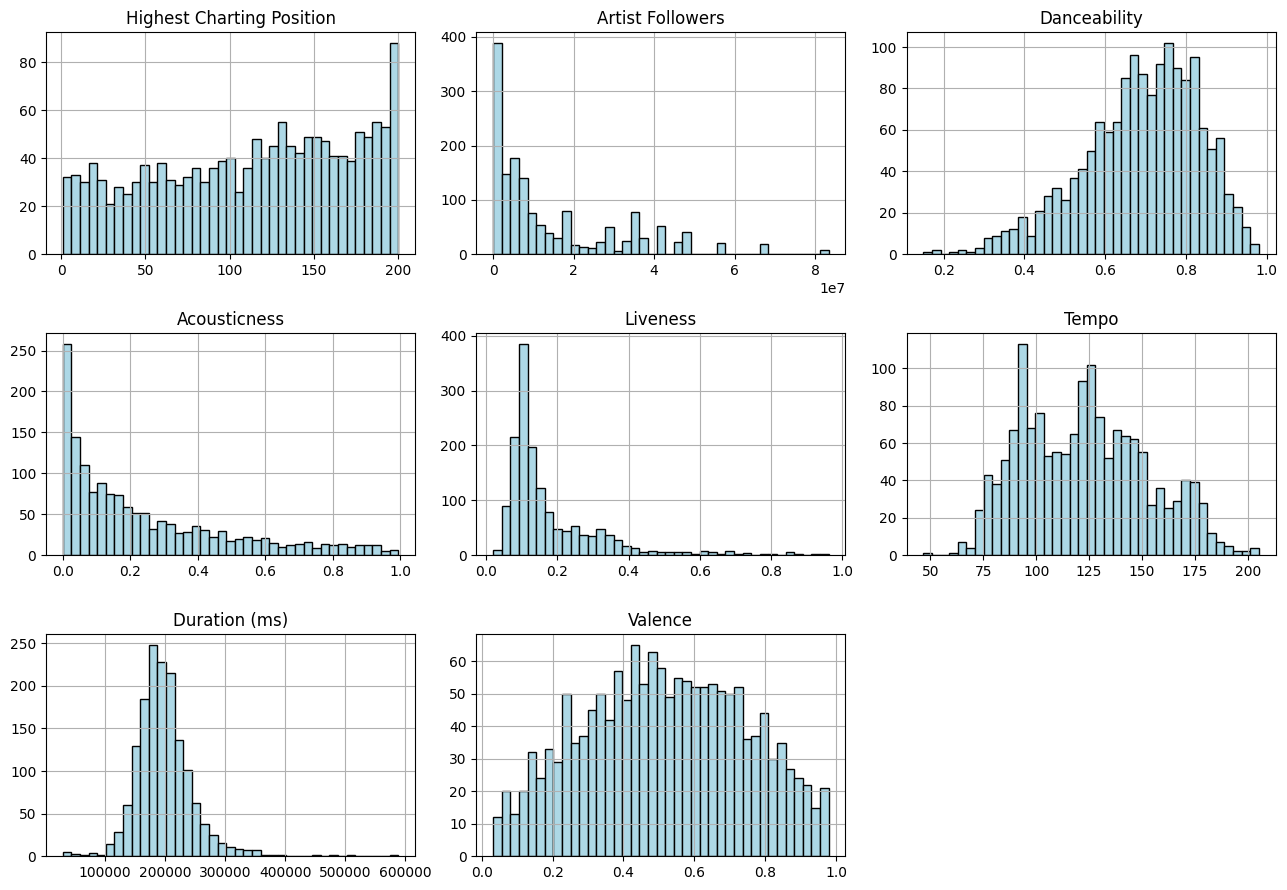

In [34]:
n = int(1556**(1/2)) # bins

df_clean.hist(figsize=(13,9), bins=n, color='lightblue', edgecolor='black')

plt.tight_layout()
plt.show()

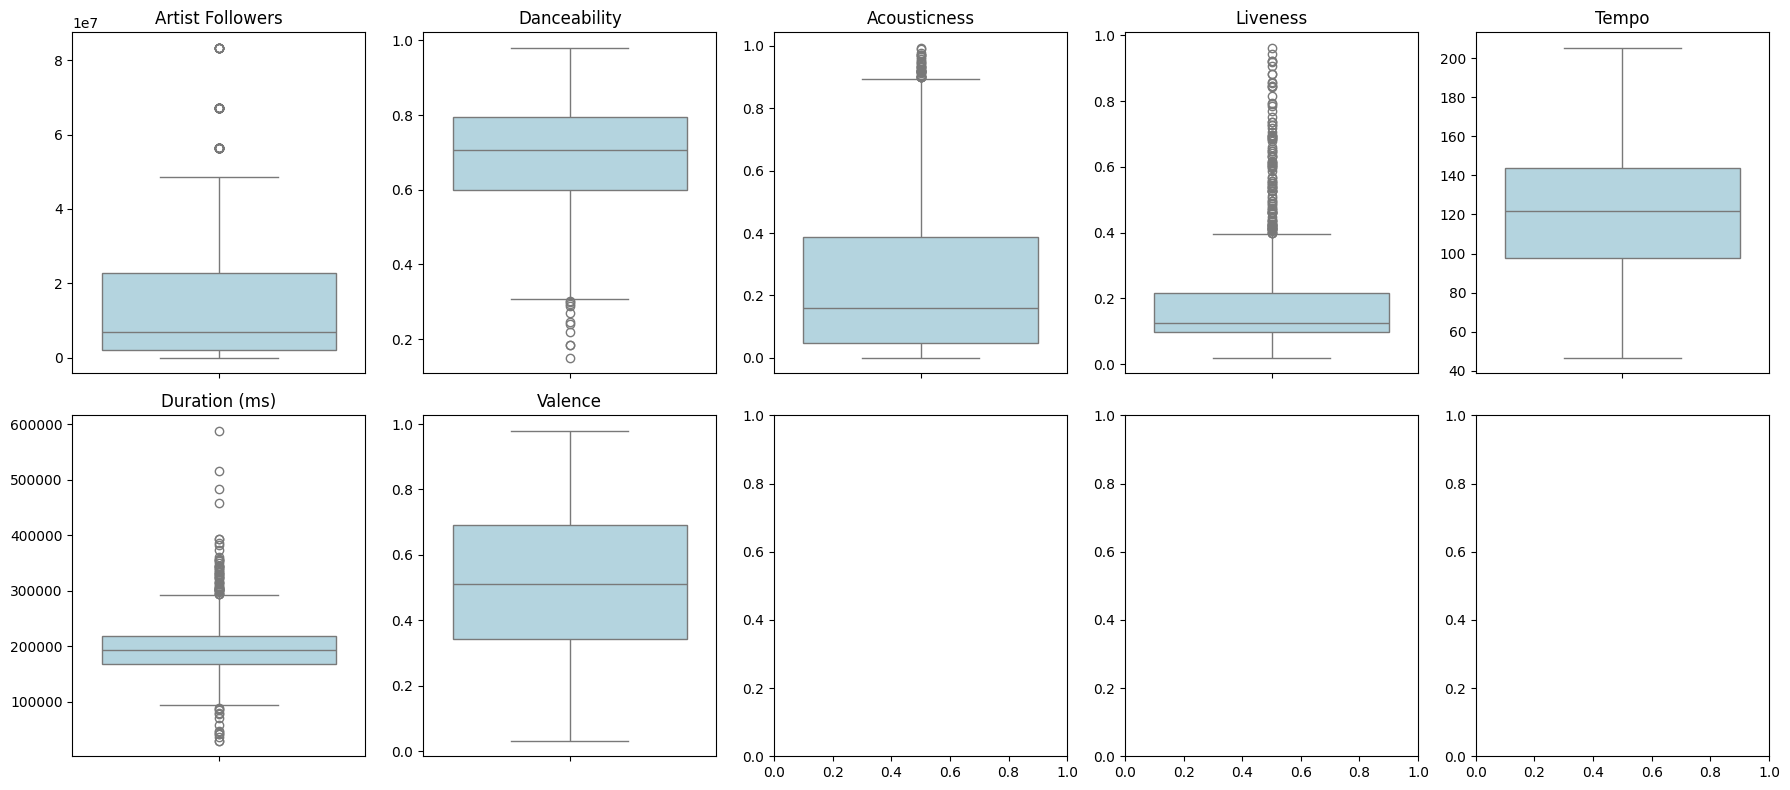

In [35]:
eda_features = ['Artist Followers', 'Danceability', 'Acousticness', 'Liveness', 'Tempo',
                'Duration (ms)', 'Valence']

# Set up a grid layout for our subplots (2 rows, 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()  # Flatten the 2D array of axes to easily loop through them

# Loop through each feature and create a boxplot
for idx, col in enumerate(eda_features):
    sns.boxplot(y=df_clean[col], ax=axes[idx], color='lightblue')
    axes[idx].set_title(col, fontsize=12)
    axes[idx].set_ylabel('')  # Clear default ylabel for a cleaner look

plt.tight_layout()
plt.show()

##Processing

In [36]:
X = df_clean.drop(target, axis = 1)
y = df_clean[target]

In [37]:
X.columns

Index(['Artist Followers', 'Danceability', 'Acousticness', 'Liveness', 'Tempo',
       'Duration (ms)', 'Valence'],
      dtype='object')

###Decision Tree Regression

In [38]:
numLoops = 100 #Arbitrarily choose how many times to run?

rms_error = np.zeros(numLoops) #Stores the RMSE score from each loop.

for idx in range(0,numLoops): #Repeats 500 times.
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
  model = DecisionTreeRegressor(max_depth=3) # Arbitrarily choosing max_depth of 3
  model.fit(X_train,y_train) #Uses the products from X_train and the correct answers in y_train to learn patterns.
  y_pred = model.predict(X_test) #Makes prediction
  rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV RMSE: {rms_error.mean().round(2)}") #Average of RMSE values from loop.

CV RMSE: 56.43


####How do we choose the tree depth?

In [39]:
max_depths = [1,2,3,4,5,6,7,8,9,10] #Runs different max depths
rms_depth = np.zeros(len(max_depths)) #Ang RMSE for depth
std_depth = np.zeros(len(max_depths)) #Consistency

numLoops = 100

for n, depth in enumerate(max_depths):
  rms_error = np.zeros(numLoops)

  for idx in range(0,numLoops):
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
    model = DecisionTreeRegressor(max_depth=depth)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

  rms_depth[n] = rms_error.mean()
  std_depth[n] = rms_error.std(ddof = 1)

In [40]:
results = pd.DataFrame({
  'Max Depth': max_depths,
  'Mean RSME': rms_depth,
  'Std RMSE': std_depth
})

results

,Max Depth,Mean RSME,Std RMSE
0,1,56.777003,1.603651
1,2,56.453141,1.439091
2,3,56.419950,1.595112
3,4,57.128932,1.664555
4,5,57.881893,1.843427
5,6,58.839145,2.330775
6,7,60.292060,2.291171
7,8,61.458158,2.704194
8,9,64.102565,2.744816
9,10,65.731760,3.130918


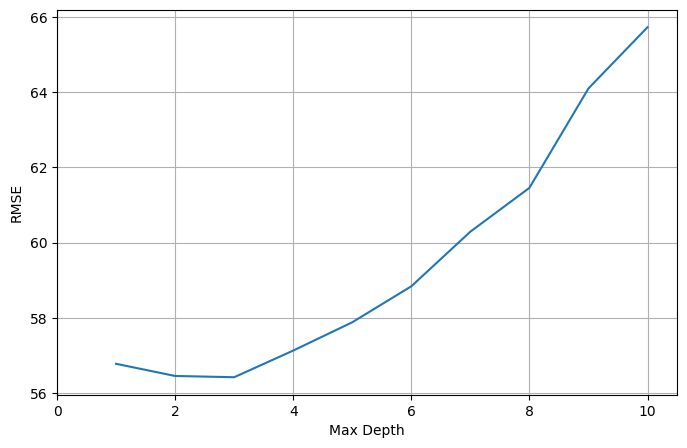

In [41]:
#Plot result
plt.figure(figsize = (8,5))
plt.plot(max_depths, rms_depth)
plt.xlabel('Max Depth')
plt.ylabel('RMSE')
plt.xlim(0, 10.5)
plt.grid()

In [42]:
#Re run with max depth = 4
numLoops = 100

rms_error = np.zeros(numLoops)

for idx in range(0, numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
  model = DecisionTreeRegressor(max_depth=4)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  rms_error[idx] = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"CV RMSE: {rms_error.mean().round(2)}")

CV RMSE: 57.36


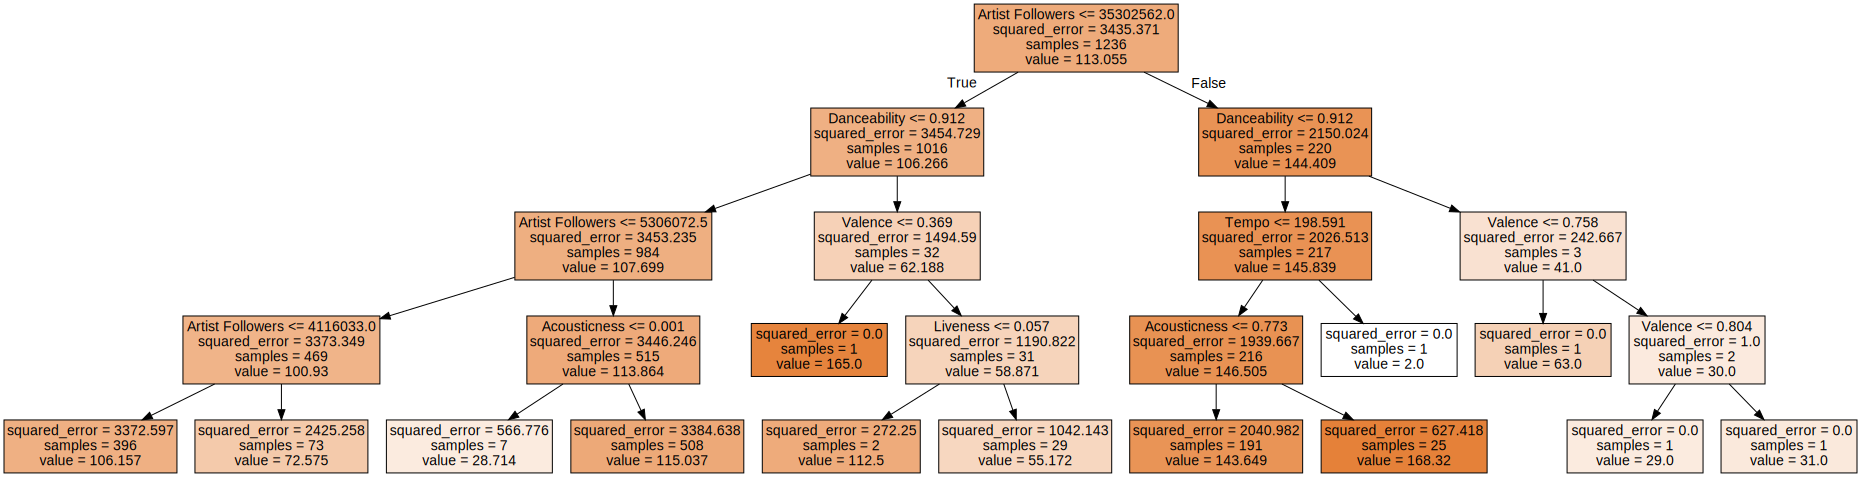

In [43]:
display(
  graphviz.Source(
    tree.export_graphviz(
      model,
      feature_names = X.columns,
      filled = True,
    )))

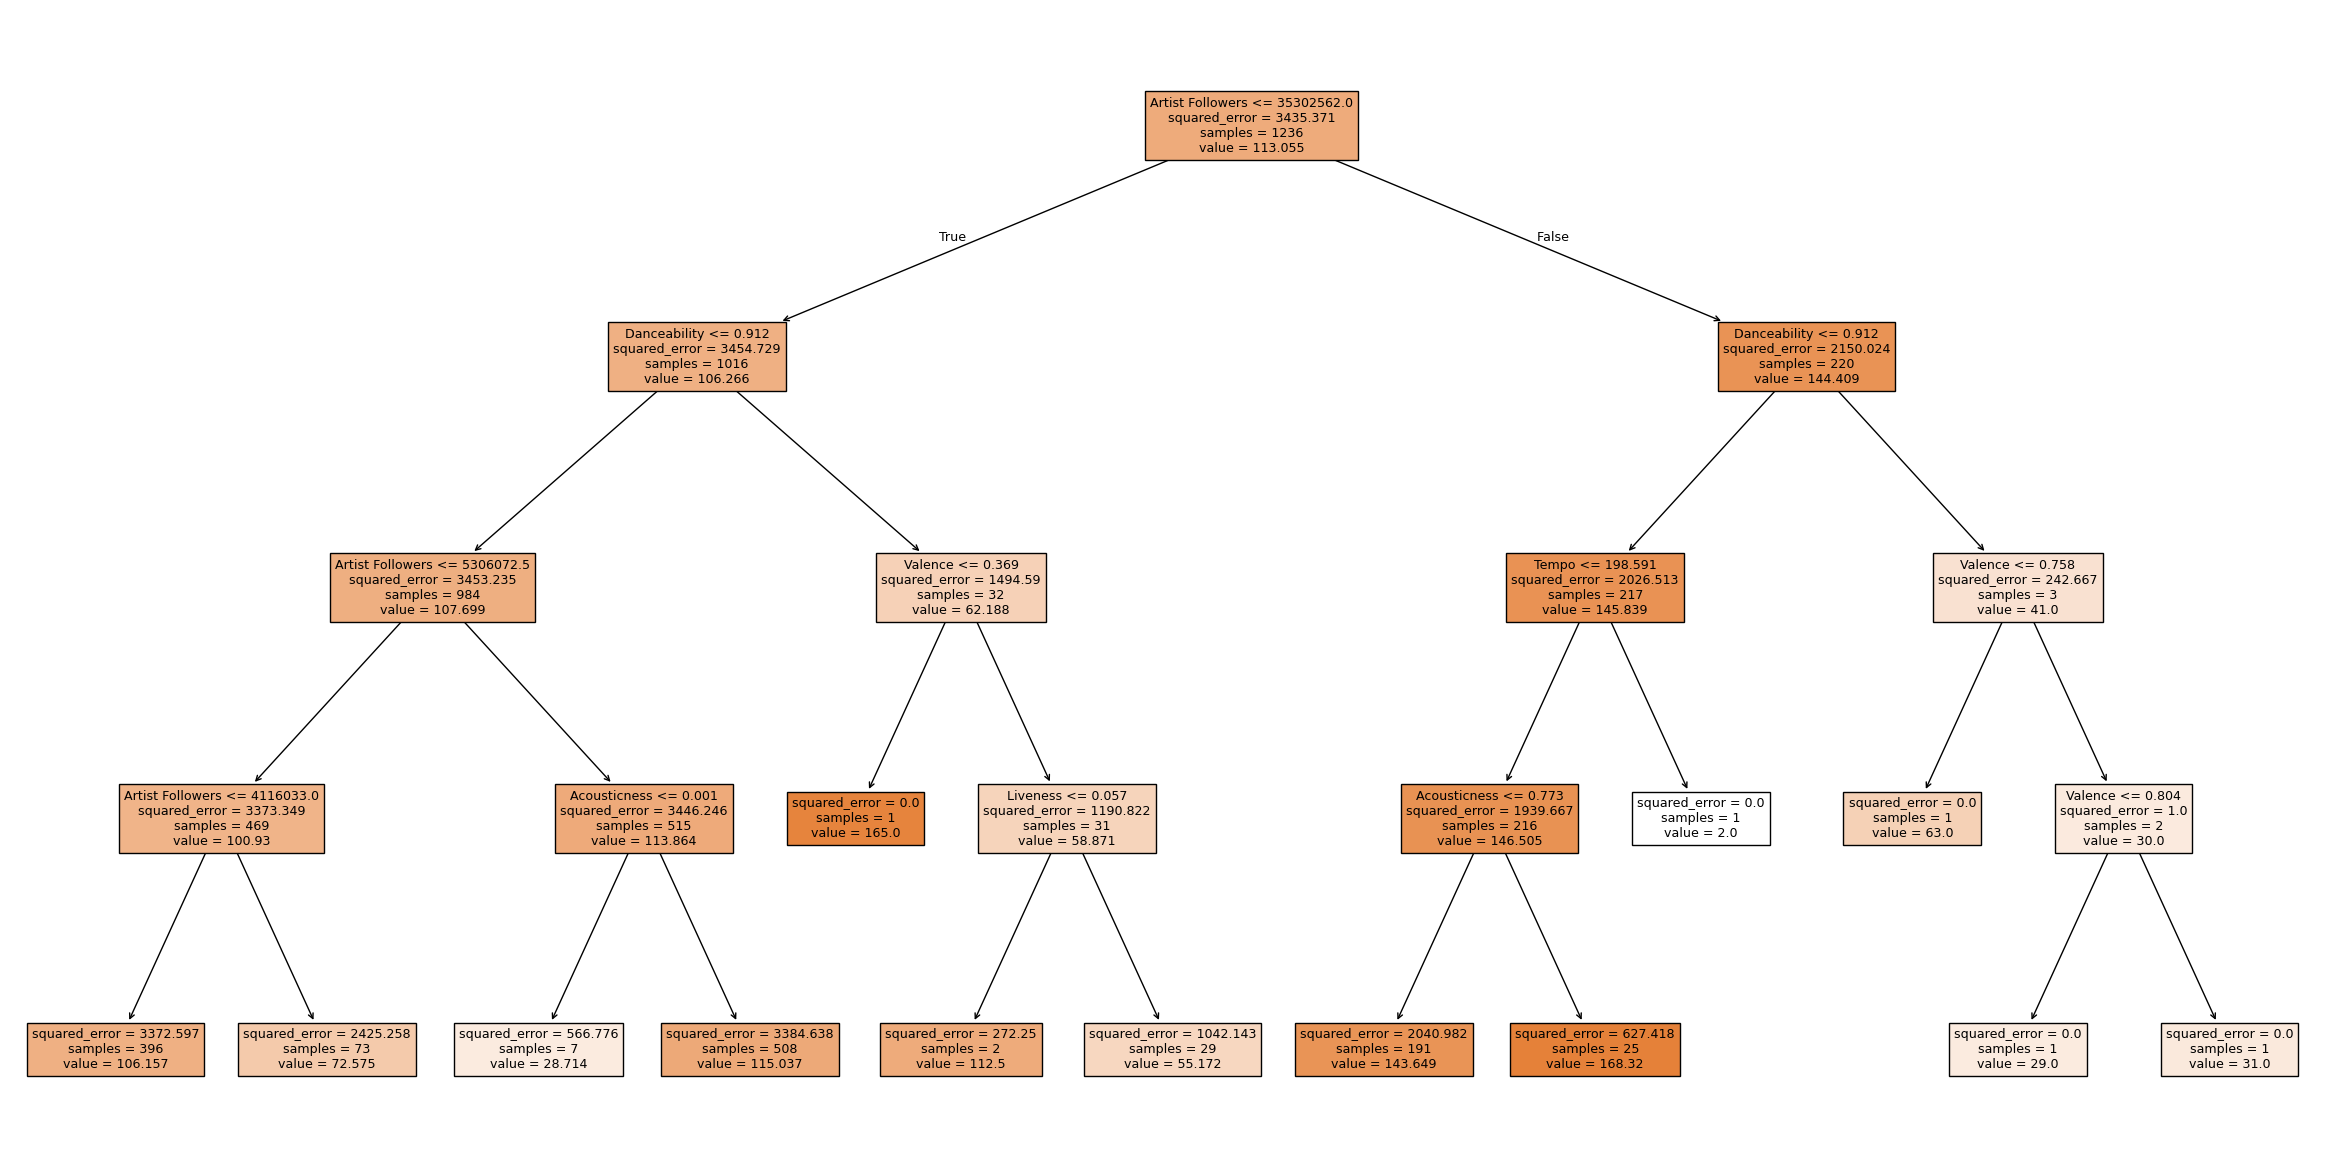

In [44]:
plt.figure(figsize=(30,15))
tree_plot = tree.plot_tree(
  model,
  feature_names = X.columns,
  filled=True,
)

###Random Forest

In [45]:
#This line intentionally left blank
numLoops = 100

mean_error = np.zeros(numLoops)

np.random.seed(42)
for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
  model = DecisionTreeRegressor(max_depth=4, random_state=0)
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  mean_error[idx] = mean_squared_error(y_test, y_pred)

print(f'RMSE: {np.sqrt(mean_error).mean()}')
print(f'RMSE_std: {np.sqrt(mean_error).std()}')
#Predictions are off by about 57.5 positions
#Model is stable

RMSE: 57.221290309531184
RMSE_std: 1.791003950662662


In [46]:
#Two parameters - n_estimators (number of trees), max_depth (number of splits)
numLoops = 100

mean_error = np.zeros(numLoops)

# np.random.seed(42)
for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)
  model = RandomForestRegressor(n_estimators = 10) # n_estimators is number of trees in forest. Note: you can also choose max_depth for RFs
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  mean_error[idx] = mean_squared_error(y_test, y_pred)

print(f'RMSE: {np.sqrt(mean_error).mean()}')
print(f'RMSE_std: {np.sqrt(mean_error).std()}')
np.sqrt(mean_error)[:50]

RMSE: 58.78681595015375
RMSE_std: 1.716289128399636


array([58.78111332, 56.53248072, 59.09374105, 56.90887349, 56.67374769,
       58.02571323, 57.98480575, 57.99944556, 57.18240189, 58.61065762,
       57.69635582, 56.61090254, 60.81376788, 61.49976291, 57.17549127,
       57.69575659, 59.39898344, 59.25851138, 60.00342643, 57.93243004,
       57.63928883, 59.12745422, 60.08136366, 57.05356895, 59.87970522,
       59.16924771, 56.59575177, 61.6459045 , 57.53069127, 58.36192875,
       58.46167408, 60.5944938 , 59.3715585 , 57.93375452, 57.07016964,
       58.23057195, 55.81023443, 57.68977628, 56.99478426, 59.29407956,
       58.47506929, 57.62673147, 59.08298466, 60.21110229, 58.6828127 ,
       57.97412867, 61.49117973, 60.38732727, 60.69530515, 56.00396088])

####How do you choose number of trees?

In [47]:
num_trees = range(10,60,10)
cv_loops = 100
rmse_results = np.zeros(len(num_trees))
std_results = np.zeros(len(num_trees))

for n, trees in enumerate(num_trees):
  rmse_cv = np.zeros(cv_loops)
  np.random.seed(42)
  for i in range(cv_loops):
    X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20)
    rfModel = RandomForestRegressor(n_estimators=trees)
    rfModel.fit(X_train, y_train)
    y_pred_rf = rfModel.predict(X_test)
    rmse_cv[i] = np.sqrt(mean_squared_error(y_test, y_pred_rf))

  print(trees,' trees finished.')
  rmse_results[n] = rmse_cv.mean()
  std_results[n] = rmse_cv.std()

10  trees finished.
20  trees finished.
30  trees finished.
40  trees finished.
50  trees finished.


In [48]:
pickle.dump(rfModel, open('rfModel.p','wb'))

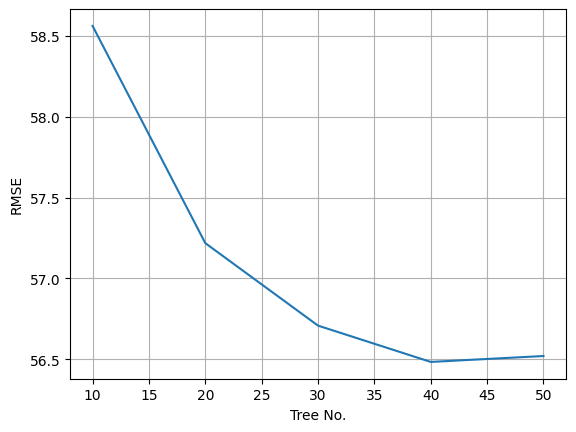

In [49]:
plt.plot(num_trees, rmse_results)
plt.xlabel('Tree No.')
plt.ylabel('RMSE')
plt.grid()

In [50]:
pd.DataFrame(zip(num_trees, rmse_results, std_results), columns='depth RMSE STDev'.split())

,depth,RMSE,STDev
0,10,58.560087,1.995829
1,20,57.218331,1.697587
2,30,56.708809,1.643428
3,40,56.484592,1.577291
4,50,56.521062,1.580934


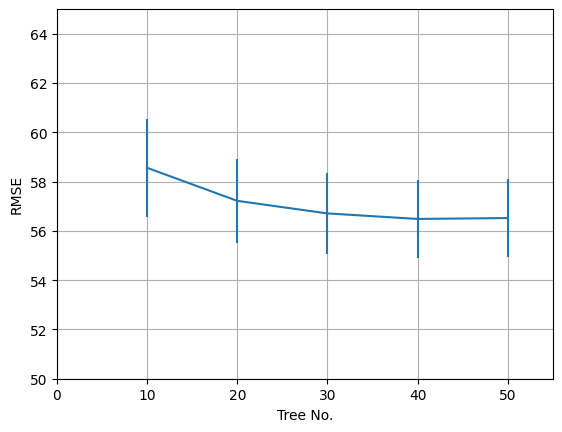

In [51]:
# plt.errorbar(num_trees, rmse_results, yerr=(std_results*2,std_results*2))
plt.errorbar(num_trees, rmse_results, yerr=std_results)
plt.xlabel('Tree No.')
plt.ylabel('RMSE')
plt.ylim(50,65)
plt.xlim(0,55)
plt.grid()

In [52]:
print(f'RMSE with 30 trees: {rmse_results[2]}')

RMSE with 30 trees: 56.70880934099874


In [53]:
len(rfModel.estimators_)

50

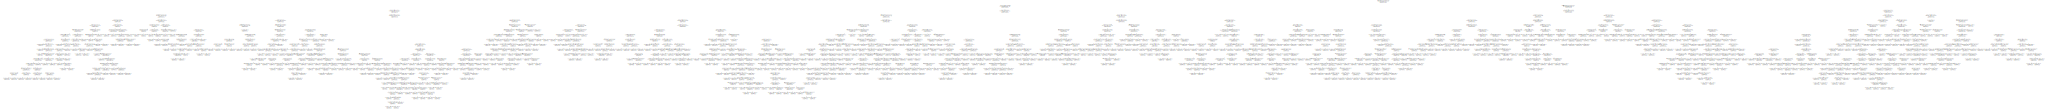

In [54]:
#Display one tree from the random forest
display(
  graphviz.Source(
    tree.export_graphviz(
      rfModel.estimators_[0],
      feature_names = X.columns,
    )
  )
)

####Find Important Predictors

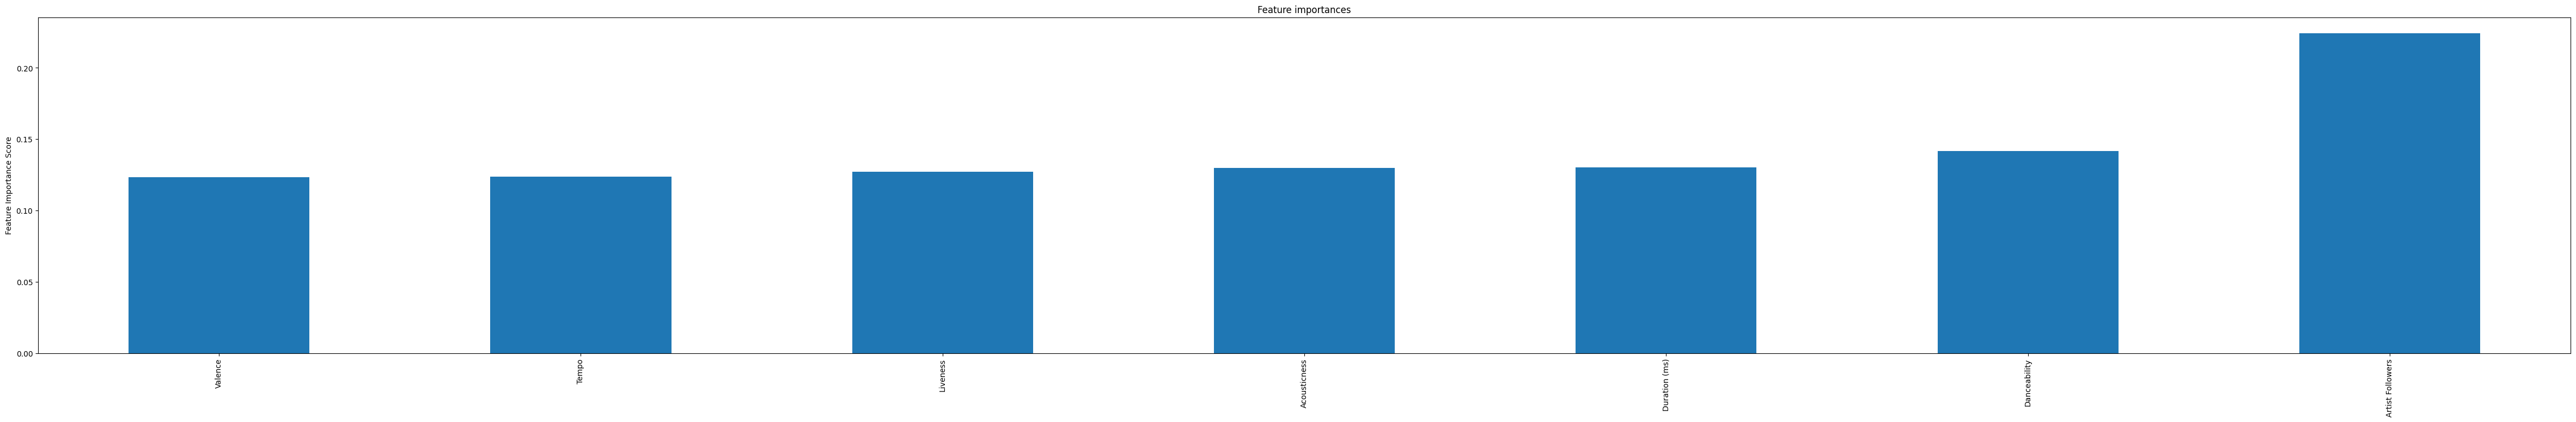

In [55]:
importances = rfModel.feature_importances_
forest_importances = pd.Series(importances, index = X.columns)

plt.figure(figsize=(60,8))
# forest_importances.plot.bar()
forest_importances.sort_values(ascending=True).plot.bar()
plt.title("Feature importances")
plt.ylabel('Feature Importance Score');

In [56]:
(forest_importances.sort_values(ascending=False)).cumsum()

,0
Artist Followers,0.224228
Danceability,0.365710
Duration (ms),0.495975
Acousticness,0.625666
Liveness,0.752876
Tempo,0.876643
Valence,1.000000


###XGBoost

In [57]:
X_train.columns.to_list()

['Artist Followers',
 'Danceability',
 'Acousticness',
 'Liveness',
 'Tempo',
 'Duration (ms)',
 'Valence']

In [58]:
numLoops = 100
mse_xgb  = np.zeros(numLoops)

for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.15)
  xgbr = xgb.XGBRegressor(objective ='reg:squarederror', verbosity=0, seed = 10)
  xgbr.fit(X_train,y_train)
  y_pred_xgb = xgbr.predict(X_test)
  mse_xgb[idx] = mean_squared_error(y_test,y_pred_xgb)

print(f'RMSE: {np.sqrt(mse_xgb).mean()}')

RMSE: 59.94886131695697


In [59]:
y_pred_xgb[0]

np.float32(85.93102)

In [60]:
y_test.to_numpy()[0]

np.int64(87)

In [61]:
my_house = X_test[:3]
my_house

,Artist Followers,Danceability,Acousticness,Liveness,Tempo,Duration (ms),Valence
1047,6852509,0.645,0.3950,0.286,140.248,48000,0.674
1481,862965,0.933,0.0253,0.104,103.981,167350,0.737
1203,56327031,0.749,0.2920,0.109,144.064,180000,0.239


In [62]:
xgbr.predict(my_house)

array([ 85.93102 ,  92.017365, 147.5723  ], dtype=float32)

In [63]:
y_test[:3]

,Highest Charting Position
1047,87
1481,14
1203,128


####XGBoost with Parameters

In [64]:
#Specify the parameters you want to try and their ranges.
param_test = {
 'max_depth'     : [3, 4, 5, 6, 7],
 'learning_rate' : [0.1, 0.2, 0.3, 0.4],
 'n_estimators'  : [20, 40, 60, 80, 100, 120, 140]
}

#Perform the grid search
#This is the Cross Validation (140)
gsearch = GridSearchCV(
    estimator = xgb.XGBRegressor(objective = 'reg:squarederror', seed = 10),
    param_grid = param_test,
    scoring = 'neg_mean_squared_error',
    cv = 5,
)

#Fit to training data
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.05, random_state = 42)
model = gsearch.fit(X_train,y_train)

#See grid search results
print(model.best_params_)

{'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 40}


Now we will fit our XGBoost model with the best parameters

In [65]:
params = model.best_params_

numLoops = 100
mse_xgb  = np.zeros(numLoops)

for idx in range(0,numLoops):
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.15)
  xgbr = xgb.XGBRegressor(
      objective ='reg:squarederror',
      verbosity=0,
      #Unpack a dictionary (* to unpack a list)
      # **params,
      learning_rate = 0.1,
      max_depth = 5,
      n_estimators = 20,
      seed = 10 #To be reproducable
  )
  xgbr.fit(X_train,y_train)
  y_pred_xgb = xgbr.predict(X_test)
  mse_xgb[idx] = mean_squared_error(y_test,y_pred_xgb)

print(f'RMSE: {np.sqrt(mse_xgb).mean().round(2)}')

RMSE: 55.46


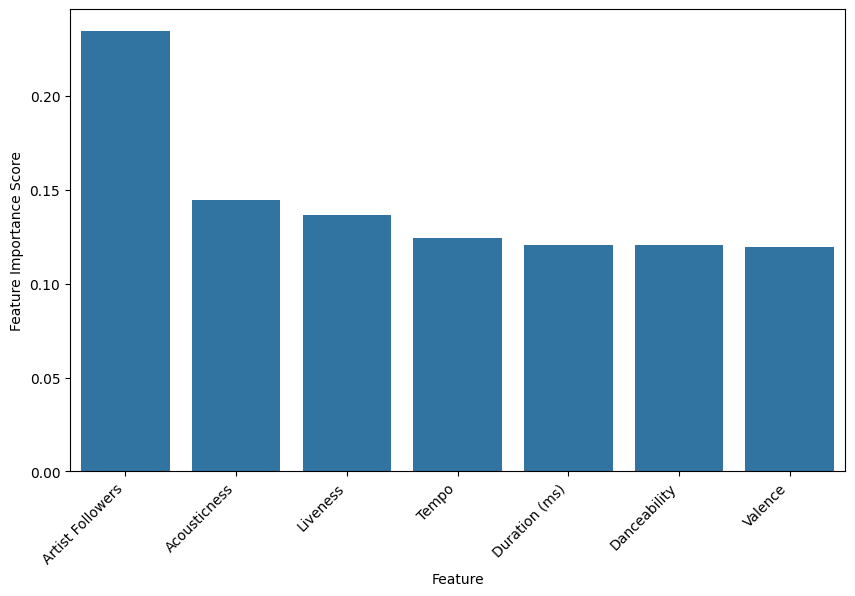

In [66]:
feat_imp = pd.Series(xgbr.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize = (10,6))
sns.barplot(x = feat_imp.index, y = feat_imp.values)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Feature Importance Score');

In [67]:
(feat_imp.sort_values(ascending=False)).cumsum()

,0
Artist Followers,0.234246
Acousticness,0.378865
Liveness,0.515473
Tempo,0.639669
Duration (ms),0.759978
Danceability,0.880281
Valence,1.000000


##Data Visualization/Communication of Results

##Conclusion and Future Work

- Focused on finding max_depth through Decision Tree Regression model.
- Ran Random Forest to find important features to drop.
- Train XGBoost with best parameters.
- Compare RMSE against all models.